In [ ]:
# Baixar dataset da RoboFlow
from roboflow import Roboflow
from pathlib import Path
import shutil

# Use sua chave API da RoboFlow para baixar a base de dados
api_key = "api-key"

rf = Roboflow(api_key=api_key)
project = rf.workspace("samrat-sahoo").project("license-plates-f8vsn")
version = project.version(3)
dataset = version.download("yolo26")

# Caminho desejado
target_dir = Path("../datasets")
target_dir.mkdir(parents=True, exist_ok=True)

# Move o dataset baixado para ../datasets
downloaded_path = Path(dataset.location)
final_path = target_dir / downloaded_path.name

if final_path.exists():
    shutil.rmtree(final_path)

shutil.move(str(downloaded_path), str(final_path))

print(f"Dataset salvo em: {final_path}")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plates-3 in yolo26:: 100%|██████████| 712/712 [00:00<00:00, 32677.64it/s]

Dataset salvo em: ../datasets/License-Plates-3


In [2]:
import os
from ultralytics import YOLO

# Modelo pré-treinado
model = YOLO("yolo26n.pt")

config_path = '../datasets/License-Plates-3/data.yaml'

In [3]:
# Apenas treinar em computador que aguente! Não recomendável fazer isso em um laptop!
results = model.train(data=config_path, epochs=200, patience=25, batch=32)

Ultralytics 8.4.50 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A4000, 15968MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../datasets/License-Plates-3/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=

In [4]:
# Gera dados de validação
results = model.val()

Ultralytics 8.4.50 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA RTX A4000, 15968MiB)
YOLO26n summary (fused): 122 layers, 2,375,226 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3371.1±1252.1 MB/s, size: 27.5 KB)
val: Scanning /home/ec06-g1/Projects/g01/src/license-plate-detection/datasets/License-Plates-3/valid/labels.cache... 70 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 70/70 73.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 7.6it/s 0.7s0.2s
                   all         70        218      0.877      0.774      0.845      0.662
         license-plate         70         84      0.887       0.84      0.896      0.686
               vehicle         68        134      0.866      0.709      0.793      0.638
Speed: 1.2ms preprocess, 3.9ms inference, 0.0ms loss, 0.5ms postprocess per image
Results saved to /home/ec06-g1/Projects/g01/src/license-plate-detection


Found https://quatrorodas.abril.com.br/wp-content/uploads/2018/09/imagem-e1536873662306.jpg locally at imagem-e1536873662306.jpg
image 1/1 /home/ec06-g1/Projects/g01/src/license-plate-detection/yolo26-test-model/imagem-e1536873662306.jpg: 448x640 1 license-plate, 1 vehicle, 3.3ms
Speed: 1.1ms preprocess, 3.3ms inference, 0.2ms postprocess per image at shape (1, 3, 448, 640)


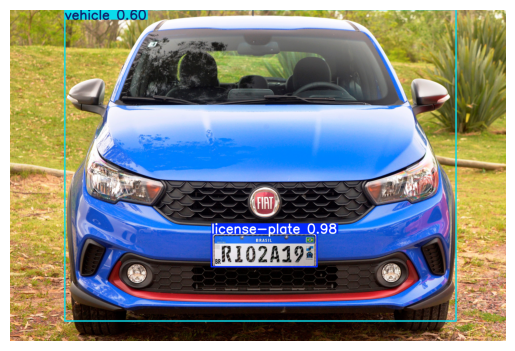

In [7]:
from matplotlib import pyplot as plt

# Testar com imagem
url_imagem = "https://quatrorodas.abril.com.br/wp-content/uploads/2018/09/imagem-e1536873662306.jpg"

results = model(url_imagem)

# Exibir resultado
plt.imshow(results[0].plot()[:, :, ::-1])
plt.axis("off")

plt.show()